In [51]:
import pandas as pd, numpy as np, matplotlib.pyplot as plt, os
import matplotlib as mpl
import matplotlib.patches as mpatches
from IPython.display import display, clear_output, Markdown

In [12]:
csv_path = "data/artificial_stand.csv"
df = pd.read_csv(csv_path)

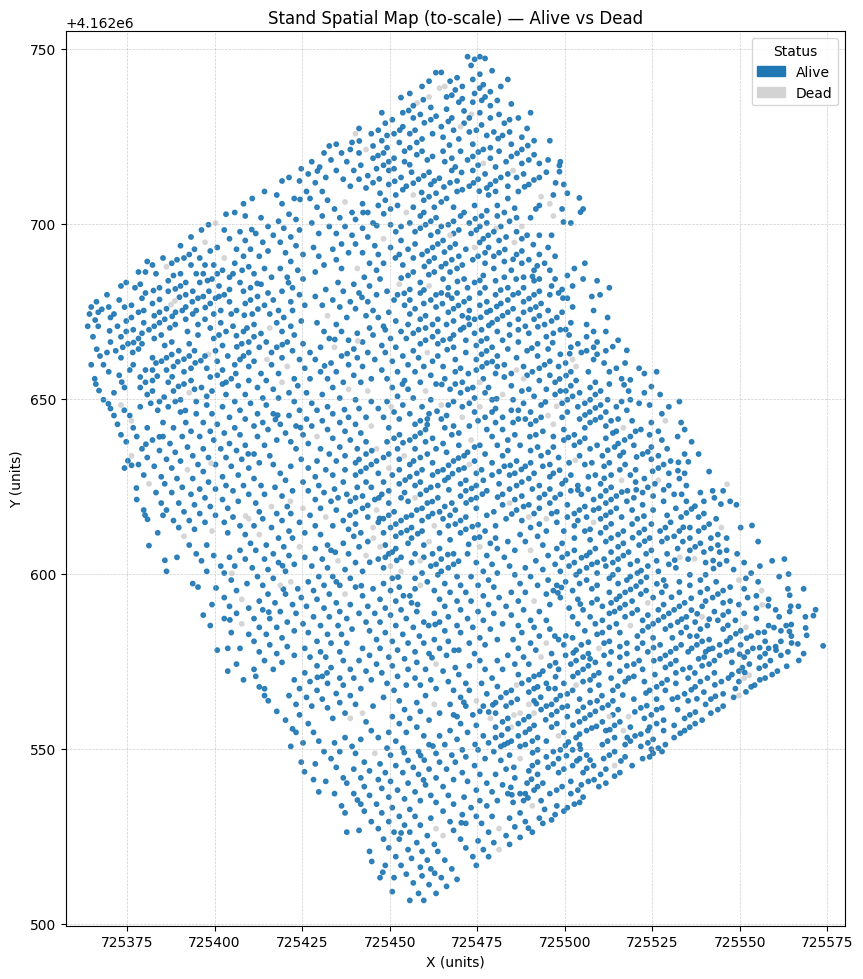

In [13]:
alive_color = "#1f77b4"    # blue
dead_color  = "lightgray" 
point_size  = 10

def _normalize(s): return ''.join(ch for ch in str(s).lower() if ch.isalnum())
def _find_column(cols, candidates):
    norm = {_normalize(c): c for c in cols}
    for cand in candidates:
        key=_normalize(cand)
        if key in norm: return norm[key]
    for k,v in norm.items():
        for cand in candidates:
            if _normalize(cand) in k: return v
    raise KeyError(f"Could not find any of {candidates} in columns: {list(cols)}")

if not os.path.exists(csv_path):
    raise FileNotFoundError(csv_path)
df = pd.read_csv(csv_path)

# Coordinate columns
x_col = _find_column(df.columns, ['X','X coord','X coordinate','Easting','x'])
y_col = _find_column(df.columns, ['Y','Y coord','Y coordinate','Northing','y'])
df[x_col] = pd.to_numeric(df[x_col], errors='coerce')
df[y_col] = pd.to_numeric(df[y_col], errors='coerce')
df = df.dropna(subset=[x_col, y_col]).copy()
if df.empty: raise ValueError("No valid X,Y rows after cleaning.")

status_col = None
try:
    status_col = _find_column(df.columns, ['status'])
except KeyError:
    pass

if status_col is None:
    
    dbh_col = _find_column(df.columns, ['pre_DBH','DBH','pre dbh','dbh_pre','pre-dbh'])
    ht_col  = _find_column(df.columns,  ['pre_HT','HT','pre ht','pre-ht','height','pre_height','preheight','preHT'])
    df[dbh_col] = pd.to_numeric(df[dbh_col], errors='coerce')
    df[ht_col]  = pd.to_numeric(df[ht_col],  errors='coerce')
    alive_mask = df[dbh_col].notna() & (df[dbh_col] > 0) & df[ht_col].notna() & (df[ht_col] > 0)
    df['status'] = np.where(alive_mask, 'Alive', 'Dead')
    status_col = 'status'
else:
    df[status_col] = df[status_col].astype(str).str.strip().str.title()


colors = np.where(df[status_col] == 'Dead', dead_color, alive_color)

# Coordinates
x = df[x_col].to_numpy()
y = df[y_col].to_numpy()

# Figure sizing
dx = float(np.max(x) - np.min(x))
dy = float(np.max(y) - np.min(y))
mx = 0.03*dx if dx>0 else 1.0
my = 0.03*dy if dy>0 else 1.0
if dx>0 and dy>0:
    if dx>=dy: fig_w, fig_h = 10, max(4, 10*(dy/dx))
    else:      fig_w, fig_h = max(4, 10*(dx/dy)), 10
else:
    fig_w, fig_h = 8, 8

# Plot
fig, ax = plt.subplots(figsize=(fig_w, fig_h))
ax.scatter(x, y, s=point_size, c=colors, alpha=0.9)
ax.set_aspect('equal', adjustable='box')
ax.set_xlim(np.min(x)-mx, np.max(x)+mx)
ax.set_ylim(np.min(y)-my, np.max(y)+my)
ax.grid(True, linestyle='--', linewidth=0.5, alpha=0.6)
ax.set_xlabel(f"{x_col} (units)")
ax.set_ylabel(f"{y_col} (units)")
ax.set_title("Stand Spatial Map (to-scale) — Alive vs Dead")

# Legend
alive_patch = mpatches.Patch(color=alive_color, label='Alive')
dead_patch  = mpatches.Patch(color=dead_color,  label='Dead')
ax.legend(handles=[alive_patch, dead_patch], title="Status", frameon=True, loc='upper right')

plt.tight_layout()

plt.show()



#### Quartile spatial map for stand

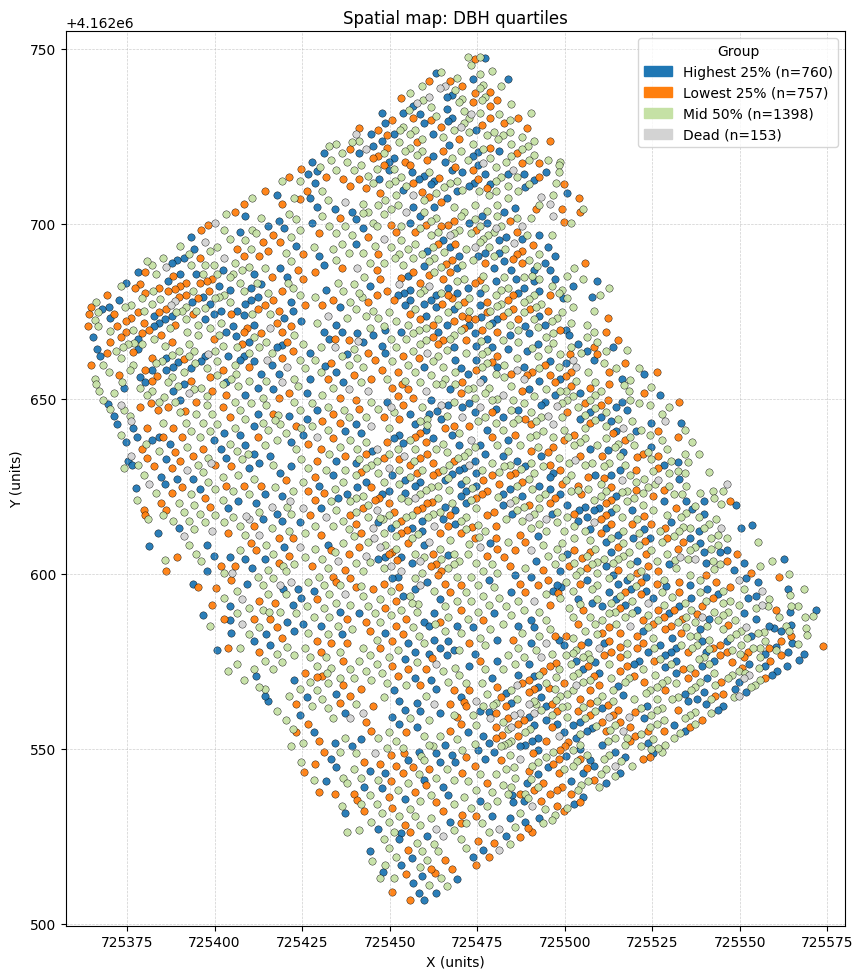

In [14]:
def _normalize(s): return ''.join(ch for ch in str(s).lower() if ch.isalnum())

def _find_column(cols, candidates):
    norm = {_normalize(c): c for c in cols}
    
    for cand in candidates:
        key=_normalize(cand)
        if key in norm: return norm[key]
    
    for k,v in norm.items():
        for cand in candidates:
            if _normalize(cand) in k: return v
    raise KeyError(f"Could not find any of {candidates} in columns: {list(cols)}")

def _ensure_status(df, dbh_candidates=None, ht_candidates=None, status_candidates=None):
    dbh_candidates = dbh_candidates or ['pre_DBH','DBH','pre dbh','dbh_pre','pre-dbh']
    ht_candidates  = ht_candidates  or ['pre_HT','HT','pre ht','pre-ht','height','pre_height','preheight','preHT']
    status_candidates = status_candidates or ['status']

    try:
        s_col=_find_column(df.columns, status_candidates)
        s=df[s_col].astype(str).str.strip().str.title()
        if set(s.unique())<=set(['Alive','Dead','Nan']):
            df['status']=np.where(s=='Alive','Alive','Dead')
            return df
    except KeyError:
        pass

    dbh_col=_find_column(df.columns, dbh_candidates)
    ht_col =_find_column(df.columns, ht_candidates)
    df[dbh_col]=pd.to_numeric(df[dbh_col],errors='coerce')
    df[ht_col] =pd.to_numeric(df[ht_col], errors='coerce')
    alive=(df[dbh_col].notna())&(df[dbh_col]>0)&(df[ht_col].notna())&(df[ht_col]>0)
    df['status']=np.where(alive,'Alive','Dead')
    return df

def _assign_dbh_quartile_groups(df, dbh_col='pre_DBH', status_col='status',
                                q_low=0.25, q_high=0.75):
    """Return a 'group' column: Dead, Lowest 25%, Mid 50%, Highest 25%."""
    d=df.copy()
    d[dbh_col]=pd.to_numeric(d[dbh_col],errors='coerce')

    alive_mask=(d[status_col]=='Alive') & d[dbh_col].notna()
    if alive_mask.any():
        q1=d.loc[alive_mask,dbh_col].quantile(q_low)
        q3=d.loc[alive_mask,dbh_col].quantile(q_high)
    else:
        q1,q3=0,1


    d['group']='Mid 50%'
    d.loc[alive_mask & (d[dbh_col]>=q3),'group']='Highest 25%'
    d.loc[alive_mask & (d[dbh_col]<=q1),'group']='Lowest 25%'
    d.loc[d[status_col]!='Alive','group']='Dead'
    return d, q1, q3

# main plotting function
def plot_dbh_quartiles_for_stand(
    csv_path="data/artificial_stand.csv",
    coord_mode='xy',              # 'xy' (to-scale using X,Y) or 'row_tree' (grid)
    size=28, edgecolor='black', edgewidth=0.3,
    color_high="#1f77b4",         # Highest 25%  (blue)
    color_low ="#ff7f0e",         # Lowest 25%   (orange)
    color_mid ="#c5e1a5",         # Mid 50%      (light green)
    color_dead="lightgray",       # Dead         
    title="Spatial map: DBH quartiles",
    show_counts=True,

    x_candidates=('X','X coord','X coordinate','Easting','x'),
    y_candidates=('Y','Y coord','Y coordinate','Northing','y'),
    row_candidates=('Row','Row no.','Row No','RowID','Row_number','Row_No'),
    tree_candidates=('Tree','Tree no.','Tree No','TreeID','Tree_number','Tree_No'),
    dbh_candidates=('pre_DBH','DBH','pre dbh','dbh_pre','pre-dbh'),
    ht_candidates=('pre_HT','HT','pre ht','pre-ht','height','pre_height','preheight','preHT')
):
    if not os.path.exists(csv_path): raise FileNotFoundError(csv_path)
    df=pd.read_csv(csv_path)

    # coords
    if coord_mode=='xy':
        x_col=_find_column(df.columns, x_candidates)
        y_col=_find_column(df.columns, y_candidates)
        df[x_col]=pd.to_numeric(df[x_col],errors='coerce')
        df[y_col]=pd.to_numeric(df[y_col],errors='coerce')
        df=df.dropna(subset=[x_col,y_col]).copy()
        xlab, ylab = f"{x_col} (units)", f"{y_col} (units)"
        equal_aspect=True
    elif coord_mode=='row_tree':
        x_col=_find_column(df.columns, tree_candidates)  # Tree on x
        y_col=_find_column(df.columns, row_candidates)   # Row on y
        df[x_col]=pd.to_numeric(df[x_col],errors='coerce')
        df[y_col]=pd.to_numeric(df[y_col],errors='coerce')
        df=df.dropna(subset=[x_col,y_col]).copy()
        xlab, ylab = "Tree", "Row"
        equal_aspect=False
    else:
        raise ValueError("coord_mode must be 'xy' or 'row_tree'.")

    df=_ensure_status(df, dbh_candidates=dbh_candidates, ht_candidates=ht_candidates)
    dbh_col=_find_column(df.columns, dbh_candidates)
    df, q1, q3=_assign_dbh_quartile_groups(df, dbh_col=dbh_col, status_col='status')

    palette={'Highest 25%':color_high,'Lowest 25%':color_low,'Mid 50%':color_mid,'Dead':color_dead}
    order=['Highest 25%','Lowest 25%','Mid 50%','Dead']

    x=df[x_col].to_numpy(); y=df[y_col].to_numpy()
    dx=float(np.max(x)-np.min(x)); dy=float(np.max(y)-np.min(y))
    mx=0.03*dx if dx>0 else 1.0; my=0.03*dy if dy>0 else 1.0
    if coord_mode=='xy' and dx>0 and dy>0:
        if dx>=dy: fig_w, fig_h = 10, max(4, 10*(dy/dx))
        else:      fig_w, fig_h = max(4, 10*(dx/dy)), 10
    else:
        fig_w, fig_h = 10, 8

    fig, ax = plt.subplots(figsize=(fig_w, fig_h))

    handles=[]
    for g in order:
        gd=df[df['group']==g]
        if gd.empty: continue
        ax.scatter(gd[x_col], gd[y_col], s=size, c=palette[g], edgecolors=edgecolor,
                   linewidths=edgewidth, alpha=0.95, label=g)
    # axis, grid, limits
    if equal_aspect: ax.set_aspect('equal', adjustable='box')
    ax.set_xlim(np.min(x)-mx, np.max(x)+mx)
    ax.set_ylim(np.min(y)-my, np.max(y)+my)
    ax.grid(True, linestyle='--', linewidth=0.5, alpha=0.6)
    ax.set_xlabel(xlab); ax.set_ylabel(ylab)
    ax.set_title(title)

    leg_labels=[]
    for g in order:
        n=(df['group']==g).sum()
        if n>0:
            leg_labels.append(f"{g} (n={n})")
    patches=[mpatches.Patch(color=palette[g], label=l) for g,l in zip([g for g in order if (df['group']==g).sum()>0], leg_labels)]
    ax.legend(handles=patches, title="Group", frameon=True, loc='upper right')

    plt.tight_layout()
    plt.show()


plot_dbh_quartiles_for_stand(
    csv_path="data/artificial_stand.csv",
    coord_mode='xy',                         
    title="Spatial map: DBH quartiles"
)

### K-row Thinning

In [59]:
def _normalize(s): return ''.join(ch for ch in str(s).lower() if ch.isalnum())

def _find_column(cols, cands):
    m={_normalize(c):c for c in cols}
    for c in cands:
        k=_normalize(c)
        if k in m: return m[k]
    for k,v in m.items():
        for c in cands:
            if _normalize(c) in k: return v
    raise KeyError(f"Could not find any of {cands} in: {list(cols)}")

def _ensure_status(d, dbh_cands=None, ht_cands=None, status_cands=None):
    dbh_cands=dbh_cands or ['pre_DBH','DBH','pre dbh','dbh_pre','pre-dbh']
    ht_cands =ht_cands  or ['pre_HT','HT','pre ht','pre-ht','height','pre_height','preheight','preHT']
    status_cands=status_cands or ['status']
    d=d.copy()
    try:
        s=_find_column(d.columns,status_cands)
        v=d[s].astype(str).str.strip().str.title()
        if set(v.unique())<=set(['Alive','Dead','Nan']):
            d['status']=np.where(v=='Alive','Alive','Dead')
            return d
    except KeyError:
        pass
    dbh=_find_column(d.columns,dbh_cands)
    ht=_find_column(d.columns,ht_cands)
    d[dbh]=pd.to_numeric(d[dbh],errors='coerce')
    d[ht]=pd.to_numeric(d[ht],errors='coerce')
    alive=(d[dbh].notna())&(d[dbh]>0)&(d[ht].notna())&(d[ht]>0)
    d['status']=np.where(alive,'Alive','Dead')
    return d

def derive_rows_from_xy(df_in, x_col, y_col, min_split=0.25, split_factor=0.45):

    d=df_in.copy()

    # PCA rotation
    X=d[[x_col,y_col]].to_numpy()
    Xc=X-X.mean(axis=0)
    _,_,Vt=np.linalg.svd(Xc, full_matrices=False)
    vx,vy=Vt[0,0],Vt[0,1]
    angle_deg=float(np.degrees(np.arctan2(vy,vx)))
    ang=np.deg2rad(angle_deg)
    c,s=np.cos(-ang),np.sin(-ang)  # rotate by -angle so PC1 -> x'
    x0,y0=d[x_col].mean(),d[y_col].mean()
    xr=c*(d[x_col]-x0)-s*(d[y_col]-y0)  # along-row
    yr=s*(d[x_col]-x0)+c*(d[y_col]-y0)  # across-row

    def _score_axis(across_vals, along_vals):
        a=np.asarray(across_vals)
        a_sorted=np.sort(a)
        if len(a_sorted)<=1:
            pitch=1.0
            centers=np.array([float(np.median(a_sorted))]) if len(a_sorted) else np.array([0.0])
        else:
            diffs=np.diff(a_sorted)
            if len(diffs)==0:
                pitch=1.0
            else:
                q75=np.percentile(diffs,75)
                big=diffs[diffs>=q75]
                pitch=float(np.median(big)) if len(big) else float(np.median(diffs))
                if not np.isfinite(pitch) or pitch<=0: pitch=1.0
            split_gap=max(min_split, split_factor*pitch)

            uniq=np.unique(a_sorted)
            centers=[]; cluster=[uniq[0]]
            for v in uniq[1:]:
                if (v-cluster[-1])>split_gap:
                    centers.append(float(np.mean(cluster))); cluster=[v]
                else:
                    cluster.append(v)
            centers.append(float(np.mean(cluster)))
        centers=np.asarray(centers)

        idx=np.abs(a[:,None]-centers[None,:]).argmin(axis=1)
        along=np.asarray(along_vals)
        within_d=[]
        for i in range(len(centers)):
            vals=np.sort(along[idx==i])
            if len(vals)>1:
                dd=np.diff(vals); dd=dd[dd>0]
                if len(dd): within_d.append(np.median(dd))
        within=float(np.median(within_d)) if len(within_d) else max(np.std(along),1.0)
        score=(pitch/within) if within>0 else np.inf
        return centers, pitch, split_gap, within, score

    cx, px, gx, wx, sx = _score_axis(xr, yr)  # across = x'
    cy, py, gy, wy, sy = _score_axis(yr, xr)  # across = y'
    if sy>sx:
        centers, pitch, split_gap, within = cy, py, gy, wy
        across_vals, along_vals = yr, xr
    else:
        centers, pitch, split_gap, within = cx, px, gx, wx
        across_vals, along_vals = xr, yr

    a=np.asarray(across_vals)
    idx=np.abs(a[:,None]-centers[None,:]).argmin(axis=1)

    row_y_means={i: float(np.mean(d[y_col].to_numpy()[idx==i])) for i in range(len(centers))}
    order=[i for i,_ in sorted(row_y_means.items(), key=lambda kv: kv[1], reverse=True)]
    rank_map={orig:i+1 for i,orig in enumerate(order)}
    row_xy=np.array([rank_map[i] for i in idx], dtype=int)

    out=d.copy()
    out['Row_XY']=row_xy
    out['_x_rot']=xr; out['_y_rot']=yr
    meta={'angle_deg':angle_deg,'pitch_est':float(pitch),'split_gap':float(split_gap),'within_est':float(within),'n_rows':int(len(centers))}
    return out, meta

# thinning helpers
def _spatial_row_rank(d, row_col, y_col):

    g=d.groupby(row_col, dropna=True)[y_col].mean()
    order=g.sort_values(ascending=False).index.tolist()
    return d[row_col].map({lab:i for i,lab in enumerate(order)})

def apply_k_row_thinning(d, row_col, k, y_col=None, protect_edges=False, edge_pad=0):

    t=d.copy()
    if y_col is not None:
        pos=_spatial_row_rank(t, row_col, y_col)
    else:
        r=pd.to_numeric(t[row_col],errors='coerce').dropna().astype(int)
        uniq=np.sort(r.unique())
        pos=t[row_col].map({lab:i for i,lab in enumerate(uniq)})
    pos=pos.fillna(-999).astype(int)

    remove=(pos % k == 0) & (pos != -999)                       
    if protect_edges:
        r=pd.to_numeric(t[row_col],errors='coerce')
        rmin,rmax=r.min(),r.max()
        protected=(r<=rmin+edge_pad)|(r>=rmax-edge_pad)
        remove=remove & (~protected)

    remove = remove & (t['status']=='Alive')                    
    t['thin_removed']=remove
    t['thin_kept']=~t['thin_removed']
    t['thin_row_index']=pos
    return t

def run_thinning_both_methods(df_in, k_list=(3,4,5)):

    d=df_in.copy()
    x=_find_column(d.columns,['X','X coord','X coordinate','Easting','x'])
    y=_find_column(d.columns,['Y','Y coord','Y coordinate','Northing','y'])
    d[x]=pd.to_numeric(d[x],errors='coerce'); d[y]=pd.to_numeric(d[y],errors='coerce')
    d=d.dropna(subset=[x,y]).copy()
    d=_ensure_status(d)
    dbh=_find_column(d.columns,['pre_DBH','DBH','pre dbh','dbh_pre','pre-dbh'])

    try:
        row_given=_find_column(d.columns,['Row','Row no.','Row No','RowID','Row_number','Row_No'])
        have_row=True
    except KeyError:
        row_given=None; have_row=False

    # XY-derived rows
    d_xy, meta = derive_rows_from_xy(d, x, y)

    out={}
    for k in k_list:
        out.setdefault(k,{})
        if have_row:
            a = apply_k_row_thinning(d, row_given, k, y_col=None)  
            a['method']='rows'; a['row_used_col']=row_given
            out[k]['rows']=a
        b = apply_k_row_thinning(d_xy, 'Row_XY', k, y_col=y)        
        b['method']='xy'; b['row_used_col']='Row_XY'
        out[k]['xy']=b

    return {'results':out,'x_col':x,'y_col':y,'dbh_col':dbh,'row_data_col':row_given,'have_row_col':have_row}

k_list=[3,4,5]
results_by_method_k = run_thinning_both_methods(df, k_list=k_list)

#### Analysis and Plots


=== k = 3 (live-only analysis) ===

Method: ROWS | Row used: Row


,n_alive_total,alive_removed,alive_kept,mean_dbh_removed_alive,mean_dbh_kept_alive,BA_removed_alive,BA_kept_alive
0,2915,970,1945,8.901649,8.890488,62302.793161,124699.582774



Method: XY | Row used: Row_XY


,n_alive_total,alive_removed,alive_kept,mean_dbh_removed_alive,mean_dbh_kept_alive,BA_removed_alive,BA_kept_alive
0,2915,900,2015,8.933333,8.876725,58237.210984,128765.164951


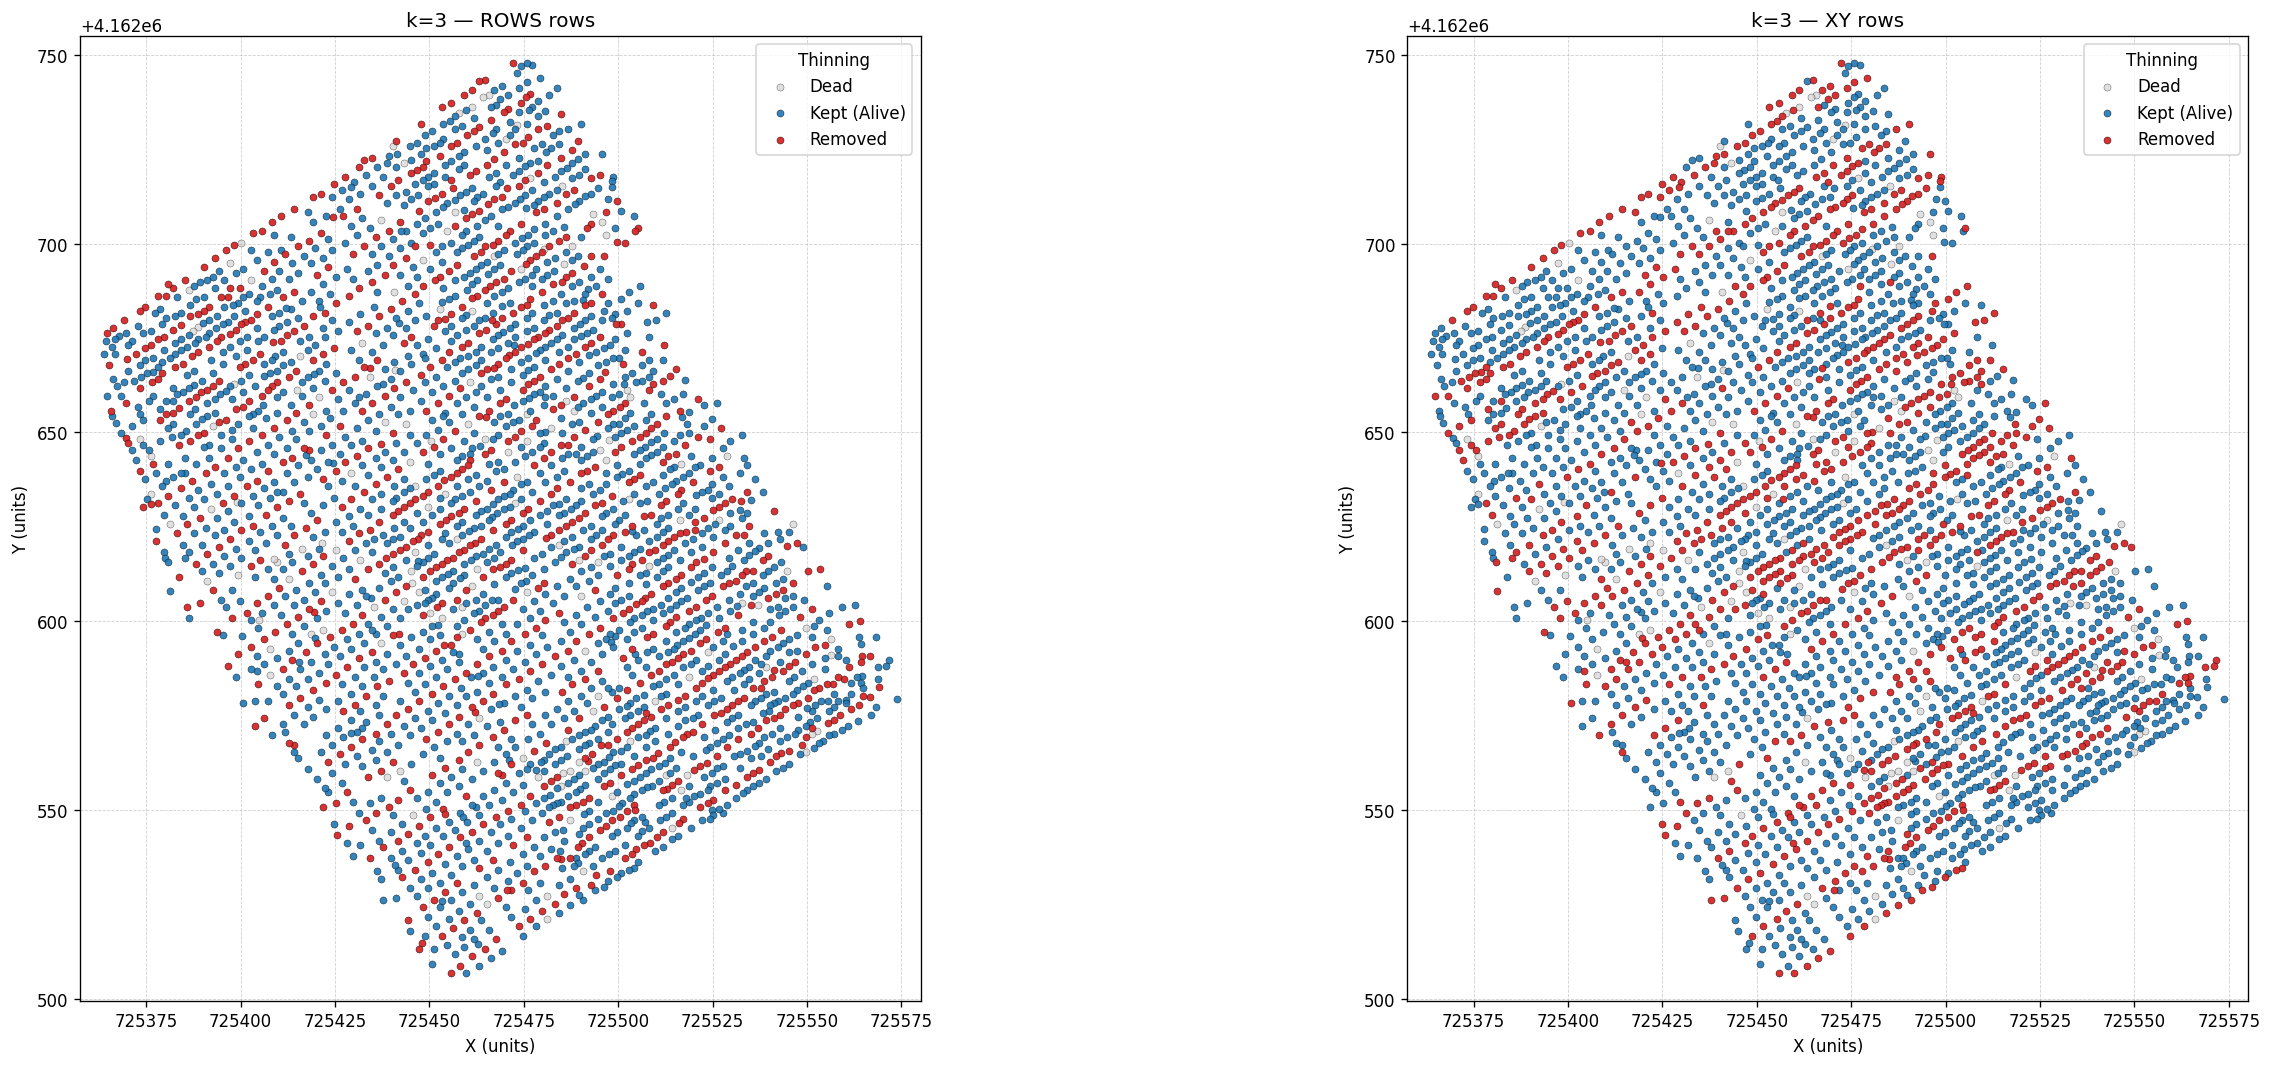


=== k = 4 (live-only analysis) ===

Method: ROWS | Row used: Row


,n_alive_total,alive_removed,alive_kept,mean_dbh_removed_alive,mean_dbh_kept_alive,BA_removed_alive,BA_kept_alive
0,2915,754,2161,8.891114,8.89528,48425.506618,138576.869317



Method: XY | Row used: Row_XY


,n_alive_total,alive_removed,alive_kept,mean_dbh_removed_alive,mean_dbh_kept_alive,BA_removed_alive,BA_kept_alive
0,2915,620,2295,8.798548,8.920044,38974.95189,148027.424045


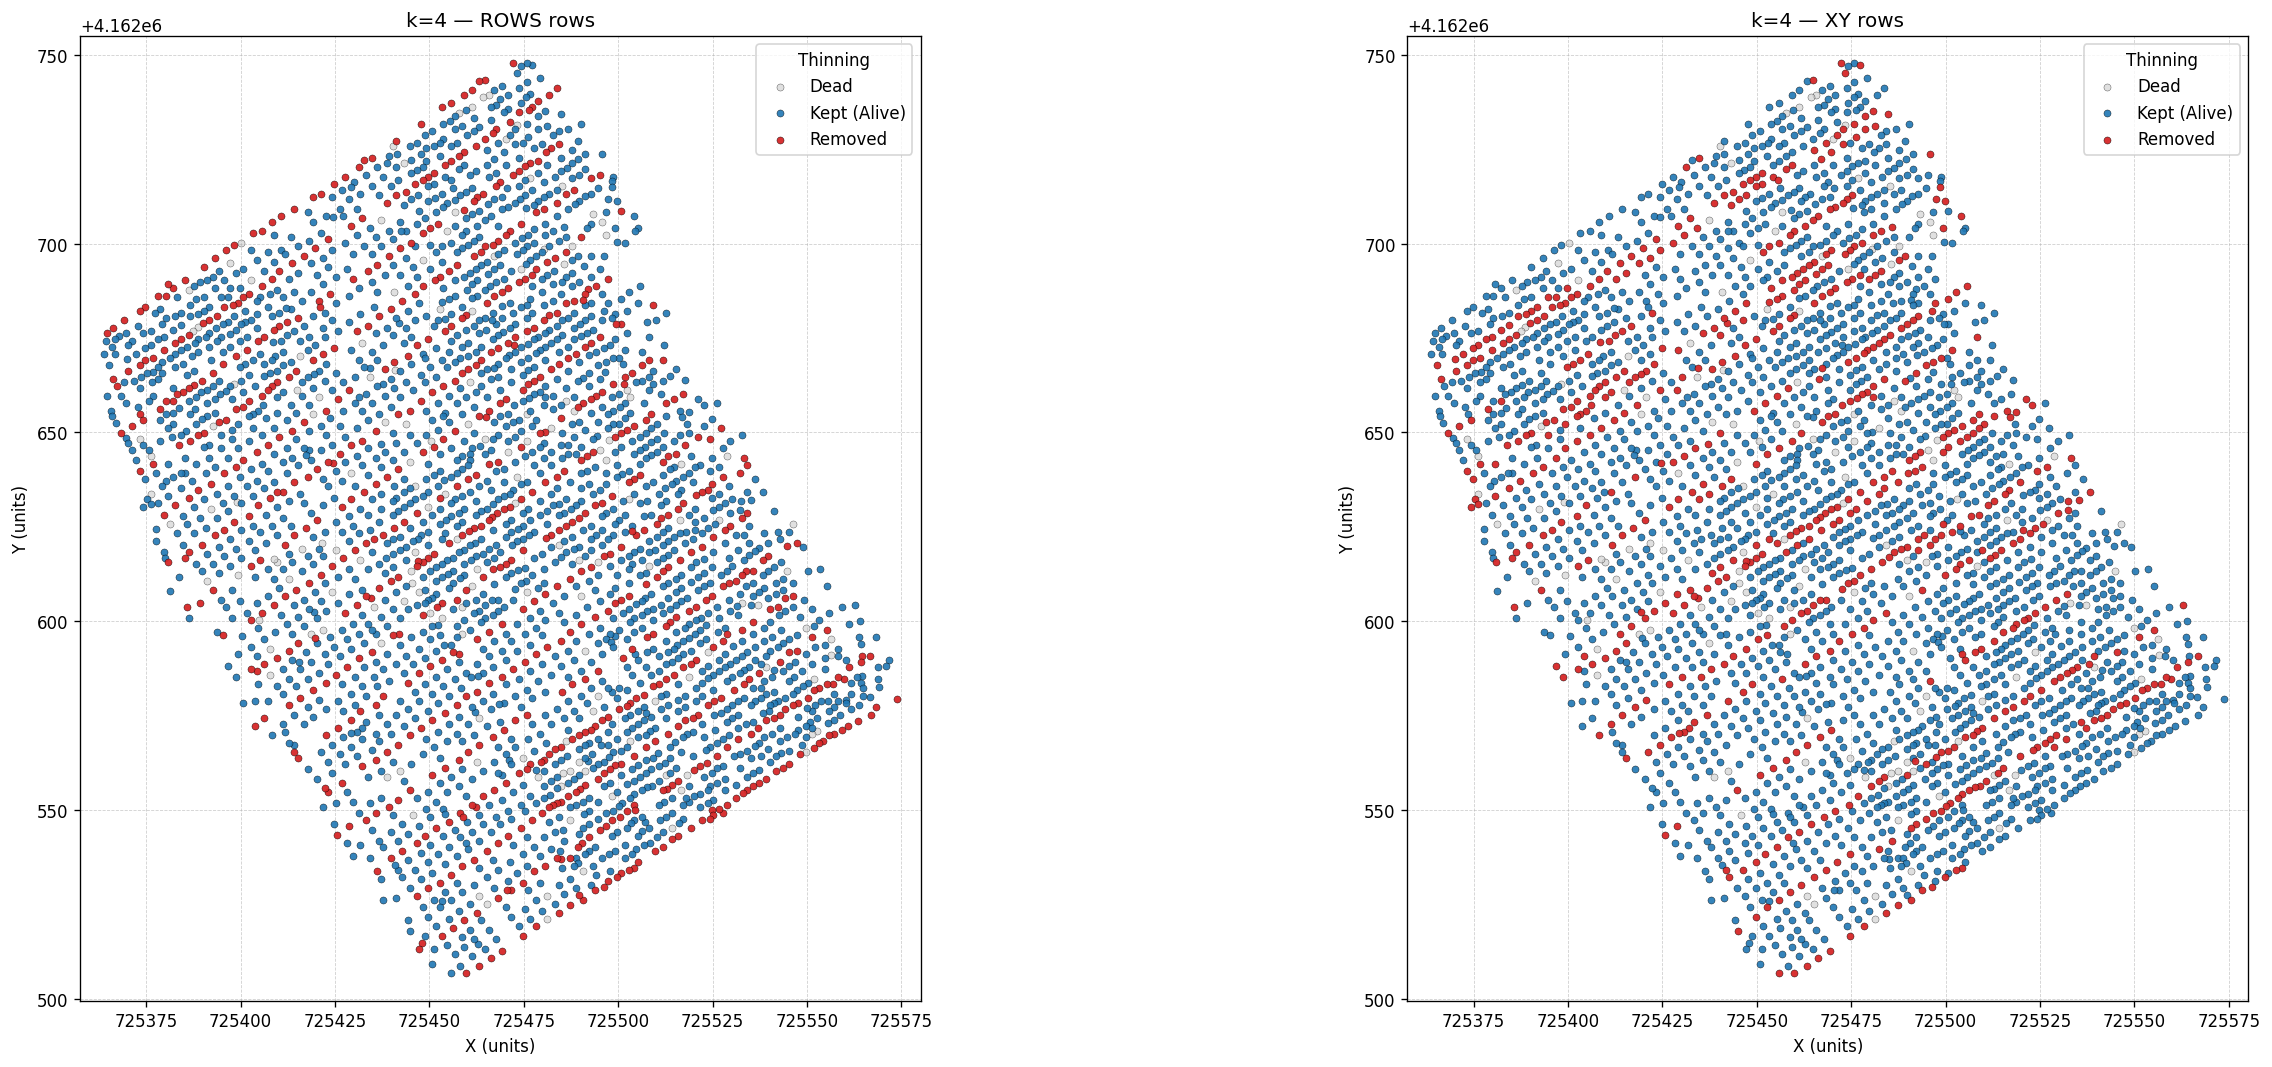


=== k = 5 (live-only analysis) ===

Method: ROWS | Row used: Row


,n_alive_total,alive_removed,alive_kept,mean_dbh_removed_alive,mean_dbh_kept_alive,BA_removed_alive,BA_kept_alive
0,2915,603,2312,8.844279,8.907223,38309.421194,148692.954741



Method: XY | Row used: Row_XY


,n_alive_total,alive_removed,alive_kept,mean_dbh_removed_alive,mean_dbh_kept_alive,BA_removed_alive,BA_kept_alive
0,2915,518,2397,8.908494,8.891114,33353.362433,153649.013502


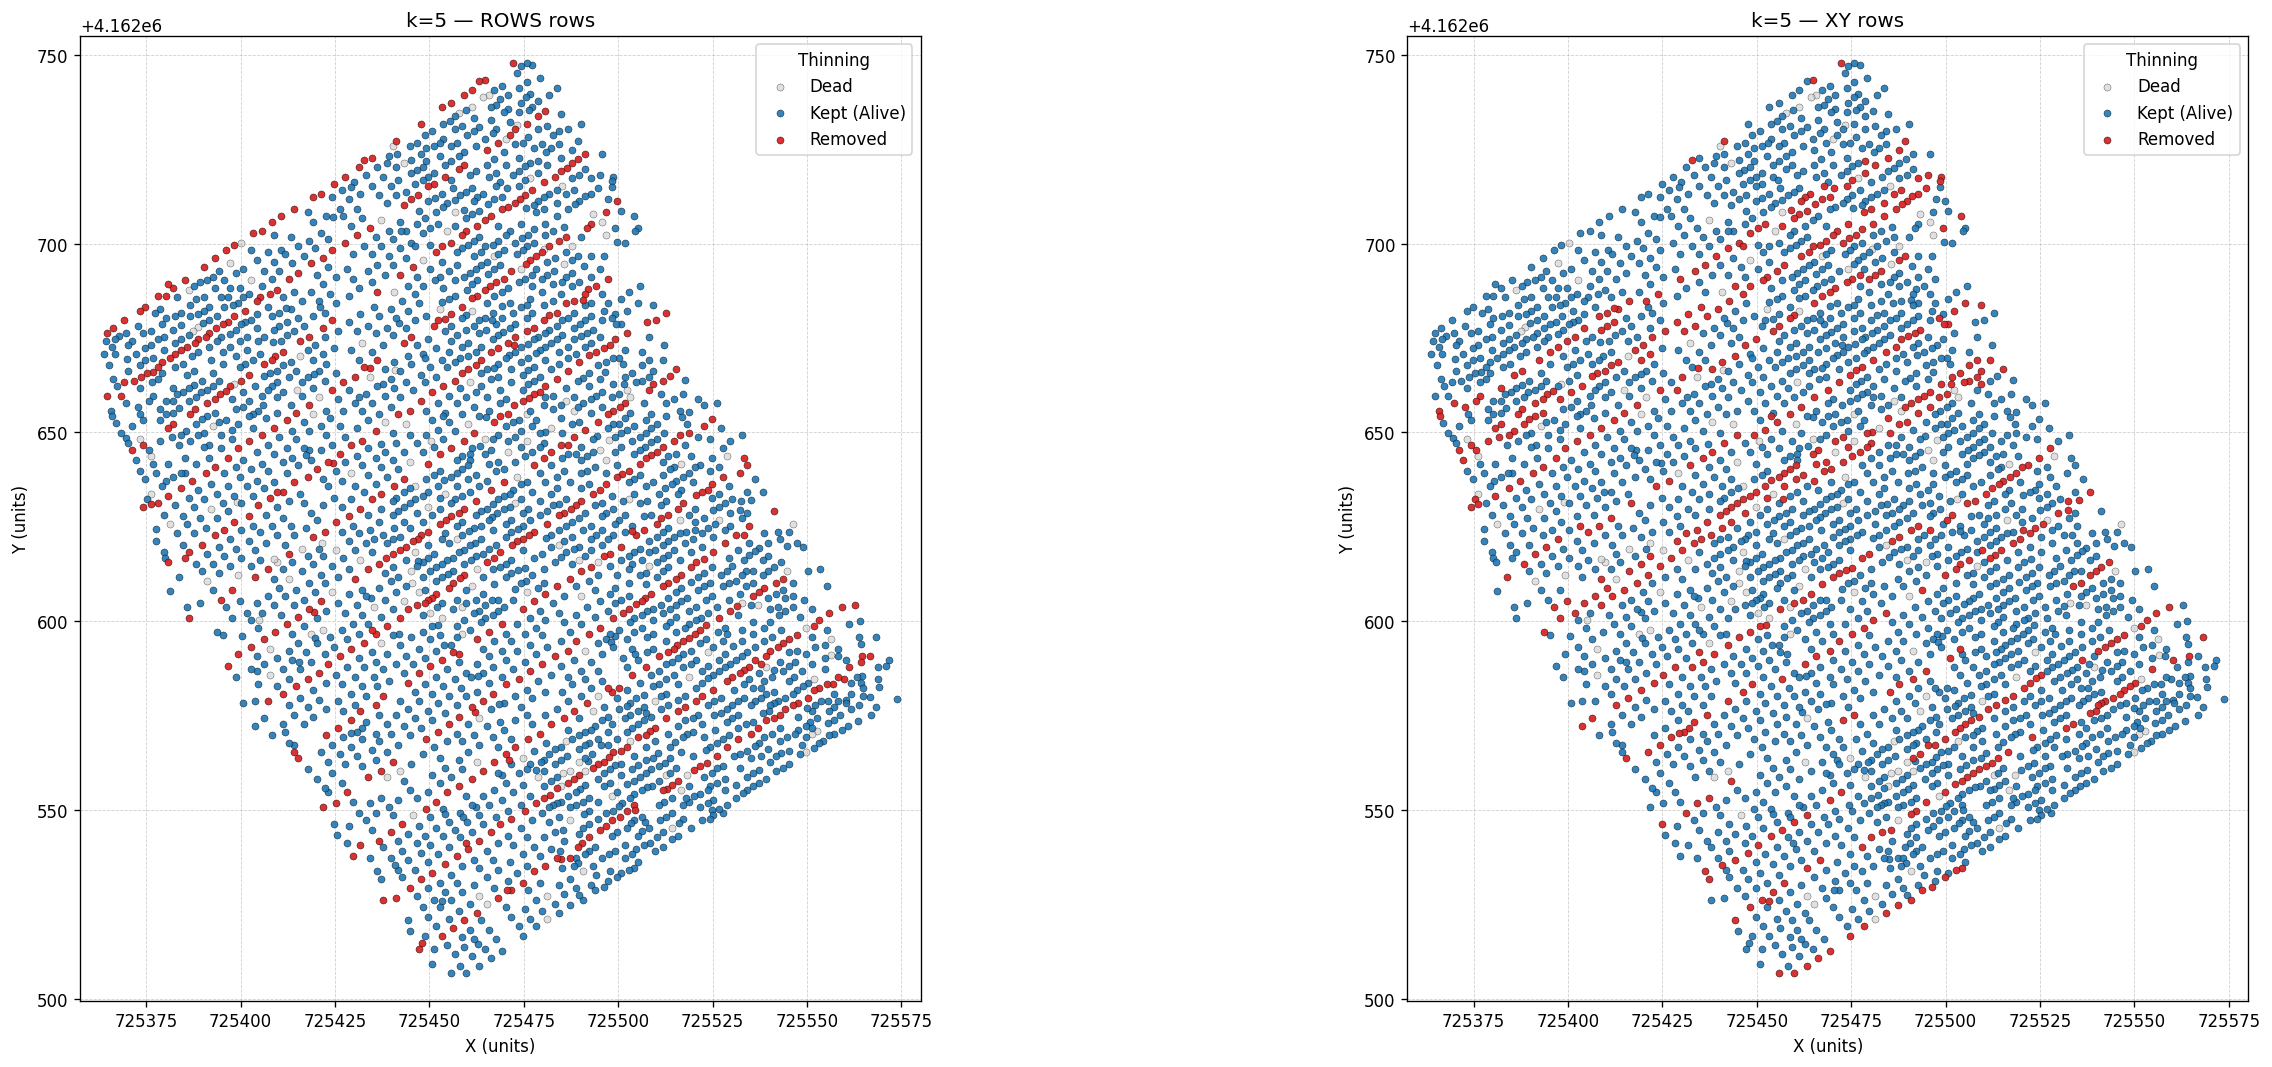

In [58]:
# Analysis & maps

def _summarize_live_only(d, dbh_col='pre_DBH'):
    d=d.copy(); d[dbh_col]=pd.to_numeric(d[dbh_col],errors='coerce')
    live=(d['status']=='Alive')
    live_rem = live & d['thin_removed']
    live_keep= live & (~d['thin_removed'])
    def BA(x):
        x=pd.to_numeric(x,errors='coerce'); return float(np.pi*(np.square(x/2)).sum())
    return pd.DataFrame({
        'n_alive_total':[int(live.sum())],
        'alive_removed':[int(live_rem.sum())],
        'alive_kept':[int(live_keep.sum())],
        'mean_dbh_removed_alive':[float(d.loc[live_rem,dbh_col].mean())],
        'mean_dbh_kept_alive':[float(d.loc[live_keep,dbh_col].mean())],
        'BA_removed_alive':[BA(d.loc[live_rem,dbh_col])],
        'BA_kept_alive':[BA(d.loc[live_keep,dbh_col])]
    })

def _plot_map_live_dead(d, x_col, y_col, title,
                        color_keep="#1f77b4", color_remove="#d62728", color_dead="lightgray",
                        size=18, edgecolor='black', edgewidth=0.25):
    x=d[x_col].to_numpy(); y=d[y_col].to_numpy()
    dx=float(x.max()-x.min()); dy=float(y.max()-y.min())
    mx=0.03*dx if dx>0 else 1.0; my=0.03*dy if dy>0 else 1.0
    if dx>0 and dy>0:
        if dx>=dy: fw,fh=10,max(4,10*(dy/dx))
        else:      fw,fh=max(4,10*(dx/dy)),10
    else: fw,fh=8,8
    ax=plt.gca()
    dead=(d['status']=='Dead')
    live_keep=(d['status']=='Alive') & (~d['thin_removed'])
    live_rem =(d['status']=='Alive') & (d['thin_removed'])

    ax.scatter(d.loc[dead,x_col],d.loc[dead,y_col],s=size,c=color_dead,alpha=0.7,
               edgecolors=edgecolor,linewidths=edgewidth,label='Dead',zorder=1)
    ax.scatter(d.loc[live_keep,x_col],d.loc[live_keep,y_col],s=size,c=color_keep,alpha=0.9,
               edgecolors=edgecolor,linewidths=edgewidth,label='Kept (Alive)',zorder=2)
    ax.scatter(d.loc[live_rem,x_col], d.loc[live_rem,y_col], s=size,c=color_remove,alpha=0.95,
               edgecolors=edgecolor,linewidths=edgewidth,label='Removed',zorder=3)

    ax.set_aspect('equal',adjustable='box')
    ax.set_xlim(x.min()-mx,x.max()+mx); ax.set_ylim(y.min()-my,y.max()+my)
    ax.grid(True,linestyle='--',linewidth=0.5,alpha=0.6)
    ax.set_xlabel(f"{x_col} (units)"); ax.set_ylabel(f"{y_col} (units)")
    ax.set_title(title); ax.legend(title="Thinning",frameon=True,loc='upper right')

# Use results from Cell 1
res=results_by_method_k['results']
x_col=results_by_method_k['x_col']; y_col=results_by_method_k['y_col']
dbh_col=results_by_method_k['dbh_col']

for k in k_list:
    methods=sorted(res[k].keys())  # e.g., ['rows','xy'] or just ['xy']
    print(f"\n=== k = {k} (live-only analysis) ===")
    for m in methods:
        d=res[k][m]
        print(f"\nMethod: {m.upper()} | Row used: {d['row_used_col'].iloc[0]}")
        display(_summarize_live_only(d, dbh_col=dbh_col))

    n=len(methods); fig,axs=plt.subplots(1,n,figsize=(12*n,9),squeeze=False)
    for i,m in enumerate(methods):
        plt.sca(axs[0,i])
        _plot_map_live_dead(res[k][m], x_col, y_col,
                            title=f"k={k} — {m.upper()} rows",
                            color_keep="#1f77b4", color_remove="#d62728", color_dead="lightgray",
                            size=18, edgecolor='black', edgewidth=0.25)
    plt.tight_layout(); plt.show()


In [57]:
def _normalize(s): return ''.join(ch for ch in str(s).lower() if ch.isalnum())

def _find_column(cols, candidates):
    m = {_normalize(c): c for c in cols}
    for cand in candidates:
        key = _normalize(cand)
        if key in m: return m[key]
    for k, v in m.items():
        for cand in candidates:
            if _normalize(cand) in k: return v
    raise KeyError(f"Could not find any of {candidates} in: {list(cols)}")

def _ensure_status(d):

    dd = d.copy()
    try:
        s_col = _find_column(dd.columns, ['status'])
        s = dd[s_col].astype(str).str.strip().str.title()
        if set(s.unique()) <= set(['Alive','Dead','Nan']):
            dd['status'] = np.where(s=='Alive','Alive','Dead')
            return dd
    except KeyError:
        pass
    dbh = _find_column(dd.columns, ['pre_DBH','DBH','pre dbh','dbh_pre','pre-dbh'])
    ht  = _find_column(dd.columns, ['pre_HT','HT','pre ht','pre-ht','height','pre_height','preheight','preHT'])
    dd[dbh] = pd.to_numeric(dd[dbh], errors='coerce')
    dd[ht]  = pd.to_numeric(dd[ht],  errors='coerce')
    dd['status'] = np.where((dd[dbh]>0) & (dd[ht]>0), 'Alive', 'Dead')
    return dd

def _ensure_volume(d):
    
    dd = d.copy()
    try:
        v = _find_column(dd.columns, ['pre_stem_vol','stem_vol','volume','pre volume'])
        dd['pre_stem_vol'] = pd.to_numeric(dd[v], errors='coerce').fillna(0.0)
        return dd
    except KeyError:
        pass
    dbh = _find_column(dd.columns, ['pre_DBH','DBH'])
    ht  = _find_column(dd.columns, ['pre_HT','HT','height'])
    dd[dbh] = pd.to_numeric(dd[dbh], errors='coerce')
    dd[ht]  = pd.to_numeric(dd[ht],  errors='coerce')
    r_m = (dd[dbh] / 100.0) / 2.0
    ba  = np.pi * (r_m ** 2)
    dd['pre_stem_vol'] = (ba * dd[ht] * 0.5).fillna(0.0)
    return dd

def thin_rows_every_k(df_in, k:int, start_row:int,
                      row_col='Row', status_col='status'):

    assert k >= 2 and 1 <= start_row <= k
    d = df_in.copy()
    d[row_col] = pd.to_numeric(d[row_col], errors='coerce')
    d['thin_decision'] = 'Dead (ignored)'
    alive = d[status_col].eq('Alive')
    rows_to_thin = ((d[row_col] - start_row) % k == 0)
    d.loc[alive & rows_to_thin, 'thin_decision'] = 'Thin'
    d.loc[alive & ~rows_to_thin, 'thin_decision'] = 'Keep'
    return d

# metrics
def summarize_thin(d_thin, metric_col, vol_col, status_col='status'):
    alive = d_thin.loc[d_thin[status_col]=='Alive'].copy()
    kept  = alive.loc[alive['thin_decision']=='Keep']
    cut   = alive.loc[alive['thin_decision']=='Thin']

    pre_vol  = float(alive[vol_col].sum()) if len(alive) else 0.0
    post_vol = float(kept[vol_col].sum())  if len(kept)  else 0.0
    rem_vol  = float(cut[vol_col].sum())   if len(cut)   else 0.0

    q1 = alive[metric_col].quantile(0.25) if len(alive) else np.nan
    q3 = alive[metric_col].quantile(0.75) if len(alive) else np.nan

    L_pre  = int((alive[metric_col] <= q1).sum()) if len(alive) else 0
    H_pre  = int((alive[metric_col] >= q3).sum()) if len(alive) else 0
    L_post = int((kept [metric_col] <= q1).sum()) if len(kept)  else 0
    H_post = int((kept [metric_col] >= q3).sum()) if len(kept)  else 0

    L_cut = L_pre - L_post
    H_cut = H_pre - H_post

    q4_removed_vol = float(cut.loc[cut[metric_col] >= q3, vol_col].sum()) if len(cut) else 0.0
    pct_q4_of_removed = (100*q4_removed_vol/rem_vol) if rem_vol>0 else np.nan

    r_q1 = (L_cut / L_pre) if L_pre>0 else np.nan
    r_q4 = (H_post / H_pre) if H_pre>0 else np.nan

    pre_med  = float(alive[metric_col].median()) if len(alive) else np.nan
    pre_mean = float(alive[metric_col].mean())   if len(alive) else np.nan
    post_med = float(kept [metric_col].median()) if len(kept)  else np.nan
    post_mean= float(kept [metric_col].mean())   if len(kept)  else np.nan

    return {
        '% trees removed': round((len(cut)/len(alive))*100, 2) if len(alive) else np.nan,
        '% volume removed': round((rem_vol/pre_vol)*100, 2) if pre_vol>0 else np.nan,
        'Trees kept': int(len(kept)),
        'Trees removed': int(len(cut)),
        'Q1 cut (count)': int(L_cut),
        'Q4 remaining (count)': int(H_post),
        'Q4 cut (count)': int(H_cut),
        'Q1 removal ratio (removed/pre)': round(r_q1, 3) if not np.isnan(r_q1) else np.nan,
        'Q4 retention ratio (post/pre)': round(r_q4, 3) if not np.isnan(r_q4) else np.nan,
        '% of removed volume from Q4': round(pct_q4_of_removed, 2) if not np.isnan(pct_q4_of_removed) else np.nan,
        'Removed volume from Q4': round(q4_removed_vol, 2),
        'Volume removed': round(rem_vol, 2),
        'Post-thinning total volume': round(post_vol, 2),
        'Pre-thinning median DBH': round(pre_med, 2) if not np.isnan(pre_med) else np.nan,
        'Pre-thinning mean DBH': round(pre_mean, 2) if not np.isnan(pre_mean) else np.nan,
        'Post-thinning median DBH': round(post_med, 2) if not np.isnan(post_med) else np.nan,
        'Post-thinning mean DBH': round(post_mean, 2) if not np.isnan(post_mean) else np.nan,
    }

def build_k_summary_table_rows(df_in, k, metric_col, vol_col, row_col='Row', status_col='status'):
    rows = []
    for start in range(1, k+1):
        d_thin = thin_rows_every_k(df_in, k, start, row_col=row_col, status_col=status_col)
        stats  = summarize_thin(d_thin, metric_col, vol_col, status_col=status_col)
        stats['Strategy']  = f'{k}-row start={start}'
        stats['k']         = k
        stats['start_row'] = start
        rows.append(stats)
    comp = pd.DataFrame(rows)
    for c in ('Q4 retention ratio (post/pre)', 'Q1 removal ratio (removed/pre)'):
        if c in comp.columns: comp[c] = pd.to_numeric(comp[c], errors='coerce')
    return comp

def style_comp_table(comp, title=None):
    show = [
        'Strategy',
        '% trees removed','% volume removed',
        'Trees kept','Trees removed',
        'Q1 cut (count)','Q1 removal ratio (removed/pre)',
        'Q4 remaining (count)','Q4 cut (count)',
        'Q4 retention ratio (post/pre)',
        '% of removed volume from Q4','Removed volume from Q4',
        'Volume removed','Post-thinning total volume',
        'start_row'
    ]
    cols = [c for c in show if c in comp.columns]
    tbl  = comp[cols].copy()

    count_cols = ['Trees kept','Trees removed','Q1 cut (count)','Q4 cut (count)','Q4 remaining (count)']
    pct_cols   = ['% trees removed','% volume removed','% of removed volume from Q4']
    ratio_cols = ['Q4 retention ratio (post/pre)','Q1 removal ratio (removed/pre)']
    money_cols = ['Removed volume from Q4','Volume removed','Post-thinning total volume']

    return (tbl.reset_index(drop=True)
            .style
            .format({c:'{:,.0f}' for c in count_cols if c in tbl})
            .format({c:'{:.2f}%' for c in pct_cols   if c in tbl})
            .format({c:'{:.3f}'  for c in ratio_cols if c in tbl})
            .format({c:'{:,.2f}' for c in money_cols if c in tbl})
            .set_caption(title or 'k-row thinning — stand analysis (ROW numbers)')
            .set_properties(**{'font-variant-numeric':'tabular-nums'})
            .hide(axis='index'))

def _plot_map_live_dead(d, x_col, y_col, title,
                        color_keep="#1f77b4", color_remove="#d62728", color_dead="lightgray",
                        size=18, edgecolor='black', edgewidth=0.25):
    x=d[x_col].to_numpy(); y=d[y_col].to_numpy()
    dx=float(x.max()-x.min()); dy=float(y.max()-y.min())
    mx=0.03*dx if dx>0 else 1.0; my=0.03*dy if dy>0 else 1.0
    if dx>0 and dy>0:
        if dx>=dy: fw,fh=8,max(5,8*(dy/dx))
        else:      fw,fh=max(5,8*(dx/dy)),8
    else: fw,fh=8,8

    fig, ax = plt.subplots(figsize=(fw, fh))
    dead=(d['status']=='Dead')
    live_keep=(d['status']=='Alive') & (d['thin_decision']=='Keep')
    live_rem =(d['status']=='Alive') & (d['thin_decision']=='Thin')

    ax.scatter(d.loc[dead,x_col],     d.loc[dead,y_col],     s=size, c=color_dead,   alpha=0.7,
               edgecolors=edgecolor, linewidths=edgewidth, label='Dead', zorder=1)
    ax.scatter(d.loc[live_keep,x_col],d.loc[live_keep,y_col],s=size, c=color_keep,   alpha=0.9,
               edgecolors=edgecolor, linewidths=edgewidth, label='Kept (Alive)', zorder=2)
    ax.scatter(d.loc[live_rem,x_col], d.loc[live_rem,y_col], s=size, c=color_remove, alpha=0.95,
               edgecolors=edgecolor, linewidths=edgewidth, label='Removed', zorder=3)

    ax.set_aspect('equal', adjustable='box')
    ax.set_xlim(x.min()-mx, x.max()+mx); ax.set_ylim(y.min()-my, y.max()+my)
    ax.grid(True, linestyle='--', linewidth=0.5, alpha=0.6)
    ax.set_xlabel(f"{x_col} (units)"); ax.set_ylabel(f"{y_col} (units)")
    ax.set_title(title); ax.legend(title="Thinning", frameon=True, loc='upper right')
    plt.tight_layout(); plt.show()

df_rows = df.copy()
df_rows = _ensure_status(df_rows)
df_rows = _ensure_volume(df_rows)

row_col = _find_column(df_rows.columns, ['Row','Row no.','Row No','RowID','Row_number','Row_No'])
x_col   = _find_column(df_rows.columns, ['X','X coord','X coordinate','Easting','x'])
y_col   = _find_column(df_rows.columns, ['Y','Y coord','Y coordinate','Northing','y'])
metric_col = _find_column(df_rows.columns, ['pre_DBH','DBH'])
vol_col    = _find_column(df_rows.columns, ['pre_stem_vol'])
df_rows[row_col] = pd.to_numeric(df_rows[row_col], errors='coerce')

k_dropdown = widgets.Dropdown(
    options=[('3-row','3'),('4-row','4'),('5-row','5')],
    value='3',
    description='Strategy:',
    layout=widgets.Layout(width='220px')
)
ui_out = widgets.Output()

def _render(choice_k):
    with ui_out:
        clear_output(wait=True)
        k = int(choice_k)
        comp = build_k_summary_table_rows(df_rows, k, metric_col, vol_col, row_col=row_col, status_col='status')
        # sort by Q4 retention ratio (desc)
        sort_col = 'Q4 retention ratio (post/pre)'
        comp_sorted = comp.sort_values(by=sort_col, ascending=False, na_position='last').reset_index(drop=True)
        display(Markdown(f"### **{k}-row Thinning**"))
        display(style_comp_table(comp_sorted, title=f'{k}-row — Stand Analysis'))
        best_start = int(comp_sorted.loc[0, 'start_row'])
        best_q4    = comp_sorted.loc[0, sort_col]
        d_best = thin_rows_every_k(df_rows, k, best_start, row_col=row_col, status_col='status')
        _plot_map_live_dead(d_best, x_col, y_col, title=f"{k}-row (Start={best_start}) Spatial Map")

def _on_change(e):
    if e['name']=='value':
        _render(e['new'])

k_dropdown.observe(_on_change, names='value')
display(widgets.VBox([
    widgets.HTML("<b>Select a thinning strategy:</b>"),
    k_dropdown,
    widgets.HTML("<hr style='margin:6px 0 12px 0;'>"),
    ui_out
]))
_render(k_dropdown.value)
